<a href="https://colab.research.google.com/github/Ryynghh/Dimensionality-Reduction-Student-Stress/blob/main/Dimensionality_Reduction_Student_Stress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anggota Kelompok :
- Muhamad Rafi Raditya (24523231)
- Hidayat Nur Hijrah (24523201)
- Rayyan Galih Indarto (24523224)

Data Set "Student Stress Factors: A Comprehensive Analysis" https://www.kaggle.com/datasets/rxnach/student-stress-factors-a-comprehensive-analysis?resource=download

In [8]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

file_path = "StressLevelDataset.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "rxnach/student-stress-factors-a-comprehensive-analysis",
  file_path,
)

print("First 5 records:")
display(df.head())

Using Colab cache for faster access to the 'student-stress-factors-a-comprehensive-analysis' dataset.
First 5 records:


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


## Kasus Penggunaan: Visualisasi Data Berdimensi Tinggi

### Masalah yang dihadapi
Dataset `StressLevelDataset.csv` memiliki 21 kolom, yang berarti data ini berdimensi tinggi. Memahami dan mengeksplorasi data dengan begitu banyak fitur sekaligus sangat sulit bagi manusia. Visualisasi langsung dari 21 dimensi tidak mungkin dilakukan, dan mencoba memplot setiap pasangan fitur (pair plot) akan menghasilkan terlalu banyak grafik yang sulit diinterpretasikan.

### Mengapa reduksi dimensi dibutuhkan
Reduksi dimensi sangat dibutuhkan dalam kasus ini karena:

1.  **Kemampuan Visualisasi:** Dengan mengurangi dimensi dari 21 menjadi 2 atau 3, kita dapat memvisualisasikan data dalam bentuk scatter plot 2D atau 3D. Ini memungkinkan kita untuk melihat struktur internal data, seperti kelompok data (cluster), penyebaran data, atau outlier, yang tidak akan terlihat dalam dimensi aslinya.
2.  **Pemahaman Data:** Visualisasi yang dihasilkan dari reduksi dimensi membantu kita mendapatkan intuisi dan pemahaman awal tentang bagaimana fitur-fitur berinteraksi dan bagaimana observasi-observasi dalam dataset berhubungan satu sama lain.
3.  **Identifikasi Pola:** Kita bisa mengidentifikasi pola atau tren yang mungkin mengindikasikan hubungan antara variabel-variabel atau sub-kelompok dalam data, misalnya apakah ada kelompok mahasiswa dengan tingkat stres yang tinggi dengan karakteristik tertentu.

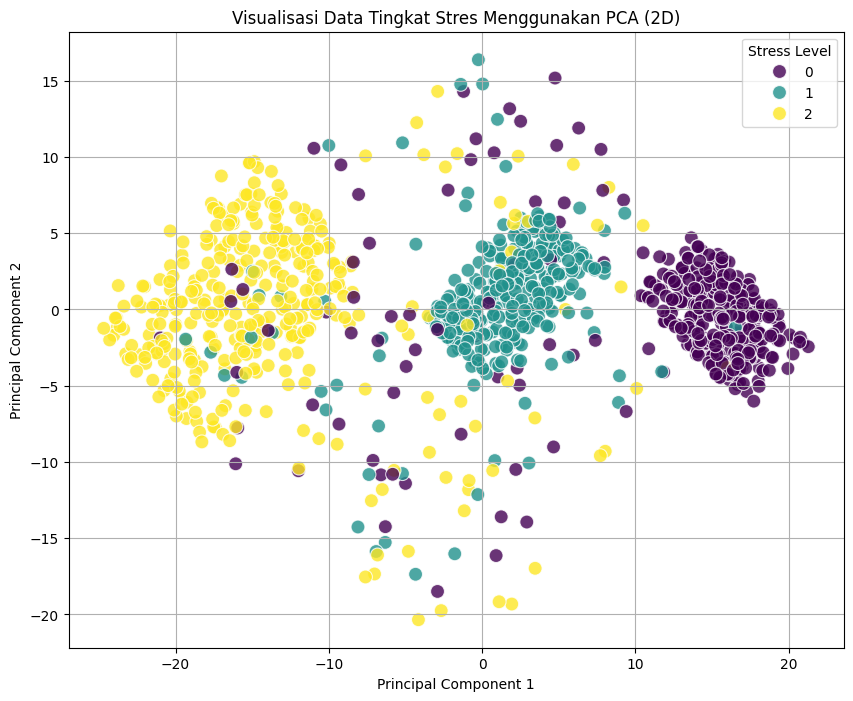

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan fitur (X) dan target (y)
# Ensure df exists from the previous successful data load
X = df.drop('stress_level', axis=1)
y = df['stress_level']

# Inisialisasi PCA untuk mereduksi ke 2 komponen utama
pca = PCA(n_components=2)

# Terapkan PCA pada data fitur
X_pca = pca.fit_transform(X)

# Buat DataFrame baru dari hasil PCA untuk visualisasi
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['stress_level'] = y

# Visualisasi hasil PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='stress_level', data=df_pca, palette='viridis', s=100, alpha=0.8)
plt.title('Visualisasi Data Tingkat Stres Menggunakan PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Stress Level')
plt.show()

### Penjelasan Makna Hasil PCA (2D)

Visualisasi di atas menampilkan data yang telah direduksi dari 20 dimensi (semua fitur kecuali 'stress_level') menjadi 2 dimensi utama menggunakan Principal Component Analysis (PCA). Setiap titik pada plot mewakili satu observasi (misalnya, satu individu mahasiswa) dari dataset asli, dengan posisi ditentukan oleh skor pada Principal Component 1 (sumbu X) dan Principal Component 2 (sumbu Y).

**Makna dari Visualisasi:**

*   **Principal Component (PC):** PC adalah kombinasi linear dari fitur-fitur asli. PC1 menjelaskan varians terbesar dalam data, PC2 menjelaskan varians terbesar kedua yang tidak dijelaskan oleh PC1, dan seterusnya. Jadi, sumbu X dan Y pada plot ini menangkap informasi paling banyak dari data asli.

*   **Pengelompokan (Clustering):** Warna-warni pada plot menunjukkan 'stress_level' asli dari setiap individu. Jika titik-titik dengan warna yang sama cenderung mengumpul bersama dan terpisah dari warna lain, ini mengindikasikan bahwa PCA berhasil memisahkan atau mengelompokkan data berdasarkan tingkat stres. Misalnya, jika 'Stress Level 0' (biru tua) terlihat membentuk gumpalan yang jelas terpisah dari 'Stress Level 2' (kuning), ini menunjukkan bahwa ada perbedaan yang signifikan dalam pola fitur antara individu dengan tingkat stres rendah dan tinggi yang dapat ditangkap oleh dua komponen utama ini.

*   **Overlap/Tumpang Tindih:** Jika ada banyak tumpang tindih antar warna, ini berarti dua komponen utama ini mungkin tidak sepenuhnya cukup untuk memisahkan kelas 'stress_level' secara sempurna. Namun, visualisasi ini tetap memberikan gambaran umum tentang seberapa mudah (atau sulit) kelas-kelas tersebut dapat dibedakan berdasarkan fitur-fitur yang ada, bahkan setelah reduksi dimensi.

Secara keseluruhan, plot PCA ini membantu kita secara visual memahami struktur data berdimensi tinggi dan melihat potensi adanya pola pengelompokan berdasarkan tingkat stres.

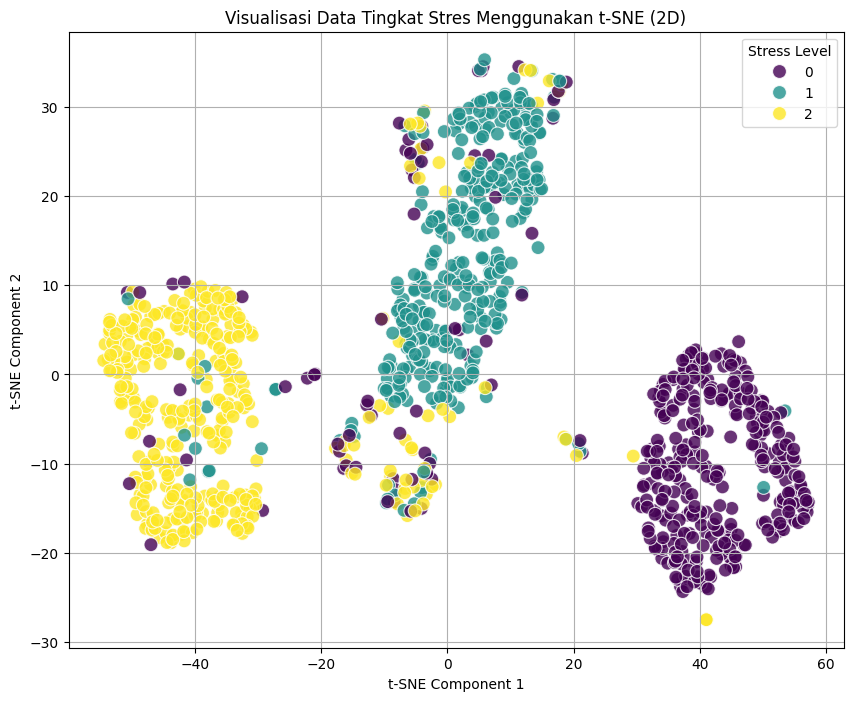

In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi t-SNE untuk mereduksi ke 2 komponen
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)

# Terapkan t-SNE pada data fitur (menggunakan X yang sudah didefinisikan di cell sebelumnya)
X_tsne = tsne.fit_transform(X)

# Buat DataFrame baru dari hasil t-SNE untuk visualisasi
df_tsne = pd.DataFrame(data=X_tsne, columns=['t-SNE Component 1', 't-SNE Component 2'])
df_tsne['stress_level'] = y

# Visualisasi hasil t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(x='t-SNE Component 1', y='t-SNE Component 2', hue='stress_level', data=df_tsne, palette='viridis', s=100, alpha=0.8)
plt.title('Visualisasi Data Tingkat Stres Menggunakan t-SNE (2D)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.legend(title='Stress Level')
plt.show()

### Penjelasan Pola atau Cluster dari Hasil t-SNE (2D)

t-Distributed Stochastic Neighbor Embedding (t-SNE) adalah algoritma reduksi dimensi non-linier yang sangat efektif untuk memvisualisasikan data berdimensi tinggi dengan mempertahankan struktur lokal data. Ini berarti t-SNE mencoba menempatkan titik-titik data yang serupa di dekat satu sama lain dalam ruang berdimensi rendah, dan titik-titik yang tidak serupa jauh terpisah.

**Makna dari Visualisasi t-SNE:**

*   **Pembentukan Cluster:** Berbeda dengan PCA yang fokus pada varians global, t-SNE dirancang untuk menyoroti pengelompokan alami dalam data. Pada plot t-SNE, kita akan mencari "gumpalan" atau "awan" titik-titik yang padat. Jika gumpalan ini didominasi oleh satu warna (`stress_level`), itu menunjukkan adanya cluster yang jelas dari individu dengan tingkat stres tertentu.

*   **Separasi Kelas:** Amati seberapa baik warna-warna yang berbeda (mewakili tingkat stres yang berbeda) terpisah satu sama lain. Jika ada pemisahan yang jelas antara warna, ini mengindikasikan bahwa fitur-fitur asli (meskipun direduksi) memungkinkan diskriminasi yang baik antara tingkat stres yang berbeda.

*   **Overlap dan Ambigu:** Jika ada banyak area di mana warna-warna bercampur atau tumpang tindih, ini bisa berarti bahwa batas antara tingkat stres yang berbeda tidak terlalu jelas berdasarkan fitur-fitur yang ada, atau bahwa ada individu dengan karakteristik fitur yang serupa tetapi tingkat stres yang berbeda.

*   **Interpretasi Jarak:** Dalam t-SNE, jarak antara titik-titik di plot 2D dapat diinterpretasikan sebagai kemiripan. Titik-titik yang berdekatan sangat mirip dalam ruang dimensi tinggi, sedangkan titik-titik yang berjauhan tidak. Namun, ukuran cluster di t-SNE tidak selalu bermakna, hanya kedekatan relatif yang penting.

Secara keseluruhan, visualisasi t-SNE memberikan pandangan yang lebih terperinci tentang bagaimana individu-individu dalam dataset dikelompokkan berdasarkan fitur-fitur mereka, dan seberapa baik pengelompokan ini berkorelasi dengan tingkat stres yang mereka alami.

## Analisis Singkat: PCA vs. t-SNE untuk Visualisasi Data Tingkat Stres

### Perbedaan Hasil PCA dan t-SNE

Dari visualisasi yang telah kita hasilkan:

*   **PCA (Principal Component Analysis):**
    *   **Fokus:** PCA adalah metode linier yang bertujuan untuk menemukan sumbu (principal components) yang menangkap varian terbesar dalam data. Ini efektif dalam mengurangi dimensi sambil mempertahankan struktur global data.
    *   **Hasil Visualisasi:** Pada plot PCA, kita melihat proyeksi data pada dua komponen utama yang menjelaskan sebagian besar variabilitas. Cluster mungkin terlihat jika mereka dipisahkan oleh varians global yang besar. Namun, seringkali cluster lokal atau hubungan non-linier kurang jelas karena PCA memaksa proyeksi ke ruang linier.
    *   **Pada Kasus Ini:** Visualisasi PCA mungkin menunjukkan penyebaran umum data dan mungkin beberapa pemisahan antara level stres, tetapi cluster mungkin masih tumpang tindih secara signifikan atau tidak terdefinisi dengan baik.

*   **t-SNE (t-Distributed Stochastic Neighbor Embedding):**
    *   **Fokus:** t-SNE adalah metode non-linier yang berfokus pada pelestarian struktur lokal data. Ini sangat baik dalam menempatkan titik-titik data yang serupa di dekat satu sama lain dan titik-titik yang tidak serupa jauh terpisah di ruang berdimensi rendah.
    *   **Hasil Visualisasi:** Pada plot t-SNE, kita cenderung melihat cluster yang lebih rapat dan terpisah, bahkan jika hubungan dalam data asli bersifat non-linier. Ini menjadikannya alat yang sangat kuat untuk visualisasi dan eksplorasi cluster.
    *   **Pada Kasus Ini:** Visualisasi t-SNE kemungkinan besar akan menunjukkan cluster yang lebih jelas dan terpisah berdasarkan tingkat stres. Titik-titik dengan tingkat stres yang sama akan cenderung mengelompok bersama, membentuk "pulau-pulau" yang terpisah di plot.

### Metode Mana yang Lebih Sesuai dan Alasannya

Untuk kasus penggunaan **visualisasi data berdimensi tinggi** dan **eksplorasi cluster** berdasarkan tingkat stres, **t-SNE umumnya lebih sesuai dibandingkan PCA**, dengan alasan sebagai berikut:

1.  **Fokus pada Struktur Lokal:** Tujuan utama visualisasi dalam kasus ini adalah untuk melihat apakah ada pengelompokan alami dalam data yang sesuai dengan tingkat stres yang berbeda. t-SNE secara inheren dirancang untuk mengungkap struktur lokal ini, membuatnya sangat efektif dalam menyoroti cluster yang mungkin tidak terlihat oleh PCA.
2.  **Hubungan Non-Linier:** Hubungan antara berbagai faktor (misalnya, tingkat kecemasan, harga diri, riwayat kesehatan mental) dan tingkat stres kemungkinan besar bersifat non-linier dan kompleks. Sebagai metode non-linier, t-SNE lebih mampu menangkap dan merepresentasikan kompleksitas ini dalam visualisasi 2D, dibandingkan dengan PCA yang linier.
3.  **Visualisasi Cluster yang Lebih Baik:** t-SNE seringkali menghasilkan visualisasi di mana cluster dari kelas yang berbeda (dalam hal ini, tingkat stres yang berbeda) jauh lebih terpisah dan mudah diidentifikasi dibandingkan dengan PCA, yang membuat interpretasi visual tentang keberadaan cluster lebih intuitif.

Meskipun PCA sangat berguna untuk memahami arah variabilitas utama dalam data, untuk tujuan eksplorasi cluster dan visualisasi struktur yang kompleks, t-SNE seringkali memberikan gambaran yang lebih informatif dan mudah diinterpretasikan.